In [237]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_curve, auc
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall

In [211]:
df = pd.read_csv("C:\\Users\\marco\\Desktop\\DM2\\df_postoutliers.csv")

In [213]:
df

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,PCIAT-Season,SDS-Season,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,sedentary_social_withdrawal
0,Fall,5,0,Winter,3.951244,Fall,2.883533,46.00,3.947390,3.295837,...,1.098612,Spring,2.790,Fall,Spring,4.110874,Fall,3.0,2.0,1
1,Summer,9,0,Spring,4.189655,Fall,2.710420,48.00,3.850148,3.135494,...,1.101940,Fall,2.340,Fall,Fall,4.174387,Summer,0.0,0.0,0
2,Summer,10,1,Fall,4.276666,Fall,2.870662,56.50,4.338597,3.295837,...,1.098612,Summer,2.170,Fall,Fall,4.007333,Summer,2.0,0.0,0
3,Winter,9,0,Fall,4.276666,Summer,2.959708,56.00,4.414010,3.295837,...,1.098612,Winter,2.451,Summer,Summer,3.828641,Winter,0.0,1.0,0
4,Spring,18,1,Summer,4.189655,Spring,2.941154,55.00,4.356709,3.295837,...,0.712950,Spring,2.700,Spring,Spring,4.025352,Spring,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8399,Spring,7,1,Spring,4.189655,Fall,2.840865,46.07,3.912023,3.146305,...,1.098612,Spring,3.000,Spring,Summer,4.025352,Spring,0.0,0.0,0
8400,Winter,10,1,Spring,4.255613,Winter,2.962315,56.13,3.887730,3.384390,...,1.098612,Winter,3.000,Spring,Spring,4.051785,Winter,0.0,1.0,0
8401,Winter,10,1,Winter,4.262680,Winter,3.736182,49.56,3.875359,3.295837,...,1.098612,Spring,2.000,Spring,Spring,4.025352,Spring,2.0,0.0,0
8402,Fall,15,1,Spring,4.034241,Spring,3.026748,63.79,4.610158,3.468856,...,1.098612,Summer,2.000,Winter,Spring,4.110874,Fall,1.0,2.0,1


In [215]:
# 1) solo righe etichettate (il task M1 vive su queste)
df = df.dropna(subset=['sedentary_social_withdrawal']).copy()
df['sedentary_social_withdrawal'] = df['sedentary_social_withdrawal'].astype(int)

In [217]:
# 2) X senza leakage: via PCIAT (definiscono/leakano il target), sii (altro target),
#    e BIA-BIA_Activity_Level_num (entra nella definizione del target)
leak = [c for c in df.columns if "PCIAT" in c] + ["sii", "BIA-BIA_Activity_Level_num"]
numeric_df = df.select_dtypes(include=['number'])
feature_cols = [c for c in numeric_df.columns
                if c not in leak and c != 'sedentary_social_withdrawal']

In [219]:
X = numeric_df[feature_cols]
y = numeric_df['sedentary_social_withdrawal']

In [221]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [223]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, random_state=29, stratify=y)

In [225]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
norm = MinMaxScaler()
norm.fit(X_train)

X_train = norm.transform(X_train)
X_test = norm.transform(X_test)

In [227]:
ctr = Counter(y_train)
ctr

Counter({0: 5651, 1: 231})

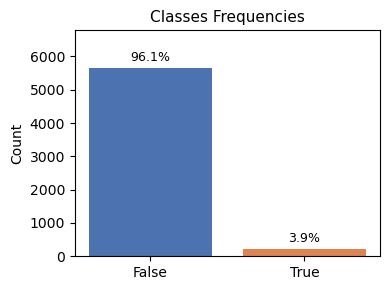

In [229]:
import matplotlib.pyplot as plt

labels = ['False', 'True']               # Etichette leggibili
values = [ctr[False], ctr[True]]         # Valori ordinati secondo le etichette
total = sum(values)
colors = ['#4C72B0', '#DD8452']          # nuova palette (blu/arancio)

plt.figure(figsize=(4, 3))               # più piccola
bars = plt.bar(labels, values, color=colors)

# Etichette sopra le barre: percentuale invece che conteggio assoluto
for bar in bars:
    yval = bar.get_height()
    pct = yval / total * 100
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + total*0.02,
              f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.title('Classes Frequencies', fontsize=11)
plt.ylabel('Count')
plt.ylim(0, max(values) * 1.2)
plt.tight_layout()
plt.savefig("class_frequencies.png", dpi=300, bbox_inches="tight")
plt.show()

In [231]:
# Faccio il decision tree (SENZA OVERSAMPLING)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

# predict
y_pred_og = clf.predict(X_test)

# Return probability estimates for the test data X.
y_val_pred_proba_og = clf.predict_proba(X_test)

print(classification_report(y_test, y_pred_og))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2423
           1       0.16      0.14      0.15        99

    accuracy                           0.94      2522
   macro avg       0.56      0.56      0.56      2522
weighted avg       0.93      0.94      0.94      2522



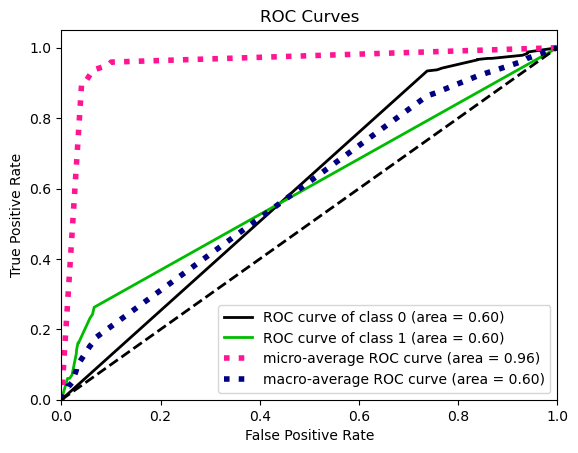

In [241]:
plot_roc(y_test, y_val_pred_proba_og)
plt.savefig('standard_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [245]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours

In [247]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 231, 1: 231})


In [249]:
def plot_pca(X_pca, y_train):
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
    plt.show()

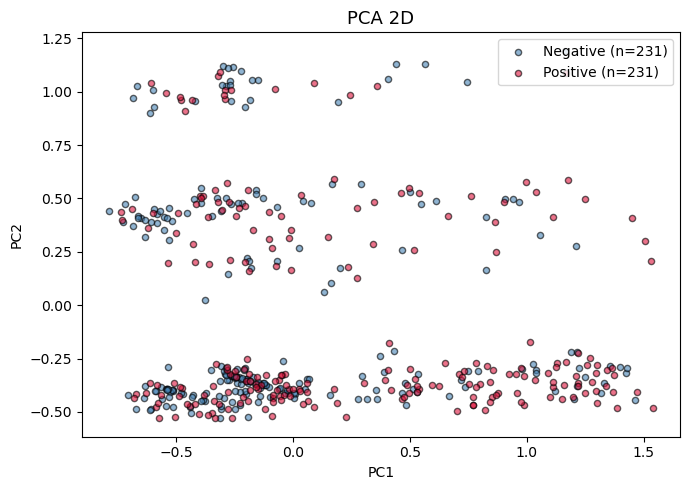

In [251]:
def plot_pca(X_pca, y, title='PCA 2D'):
    fig, ax = plt.subplots(figsize=(7, 5))
    for label, color, name in zip([0, 1], ['steelblue', 'crimson'], ['Negative', 'Positive']):
        mask = np.array(y) == label
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=color, edgecolor='k', alpha=0.6, 
                   s=20, label=f'{name} (n={mask.sum()})')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

=== Decision Tree – Random Undersampling ===
              precision    recall  f1-score   support

           0       0.99      0.69      0.81      2423
           1       0.09      0.77      0.16        99

    accuracy                           0.69      2522
   macro avg       0.54      0.73      0.49      2522
weighted avg       0.95      0.69      0.78      2522



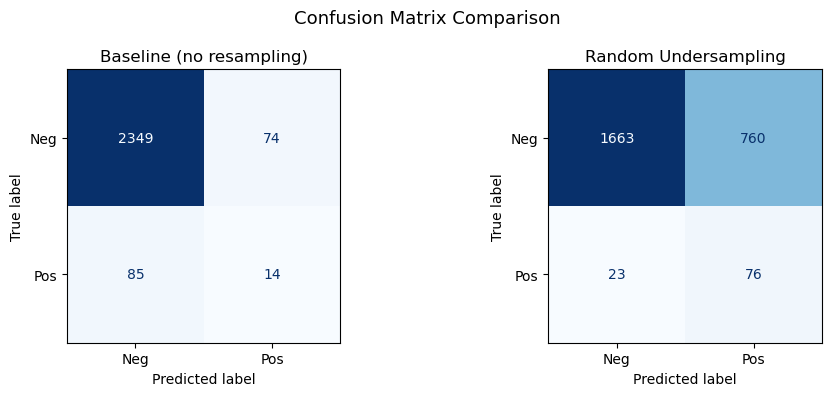

In [253]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# Fit su dati undersampled
clf_rus = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_rus.fit(X_res, y_res)

# Predict
y_pred_rus = clf_rus.predict(X_test)
y_val_pred_proba_rus = clf_rus.predict_proba(X_test)

print("=== Decision Tree – Random Undersampling ===")
print(classification_report(y_test, y_pred_rus))

# Confronto confusion matrix baseline vs RUS
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_og, ax=axes[0],
                                        display_labels=['Neg', 'Pos'],
                                        colorbar=False, cmap='Blues')
axes[0].set_title('Baseline (no resampling)')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rus, ax=axes[1],
                                        display_labels=['Neg', 'Pos'],
                                        colorbar=False, cmap='Blues')
axes[1].set_title('Random Undersampling')

plt.suptitle('Confusion Matrix Comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [255]:
import warnings
warnings.simplefilter("ignore")

In [257]:
cnn = CondensedNearestNeighbour(random_state=42, n_jobs=10)
X_res, y_res = cnn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 823, 1: 231})


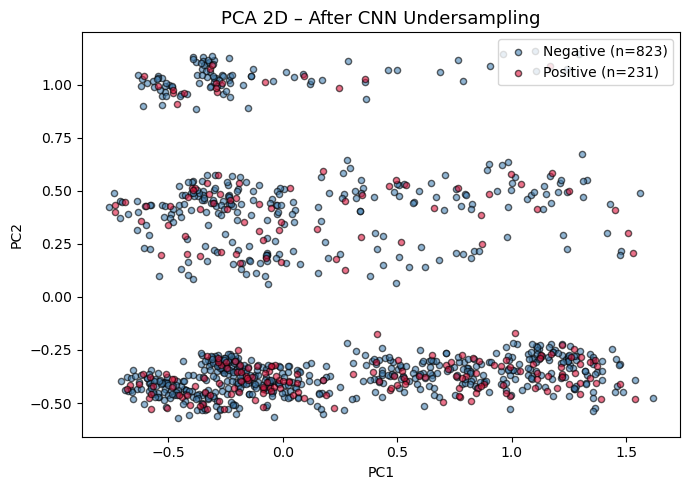

In [258]:
from sklearn.preprocessing import LabelEncoder

pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)

# Label encoding solo per la visualizzazione, non sovrascrivere y_res
le = LabelEncoder()
y_res_encoded = le.fit_transform(y_res)
plot_pca(X_pca, y_res_encoded, title='PCA 2D – After CNN Undersampling')

=== Decision Tree – CNN Undersampling ===
              precision    recall  f1-score   support

           0       0.98      0.87      0.92      2423
           1       0.13      0.46      0.20        99

    accuracy                           0.85      2522
   macro avg       0.55      0.67      0.56      2522
weighted avg       0.94      0.85      0.89      2522



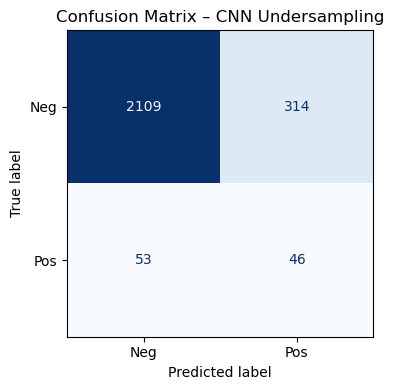

In [259]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Fit su dati CNN
clf_cnn = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_cnn.fit(X_res, y_res)

# Predict
y_pred_cnn = clf_cnn.predict(X_test)
y_val_pred_proba_cnn = clf_cnn.predict_proba(X_test)

print("=== Decision Tree – CNN Undersampling ===")
print(classification_report(y_test, y_pred_cnn))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cnn, ax=ax,
                                        display_labels=['Neg', 'Pos'],
                                        colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – CNN Undersampling')
plt.tight_layout()
plt.show()

In [260]:
tl = TomekLinks()
X_tl, y_tl = tl.fit_resample(X_train, y_train)
print(f"Resampled dataset shape: {Counter(y_tl)}")

Resampled dataset shape: Counter({0: 5582, 1: 231})


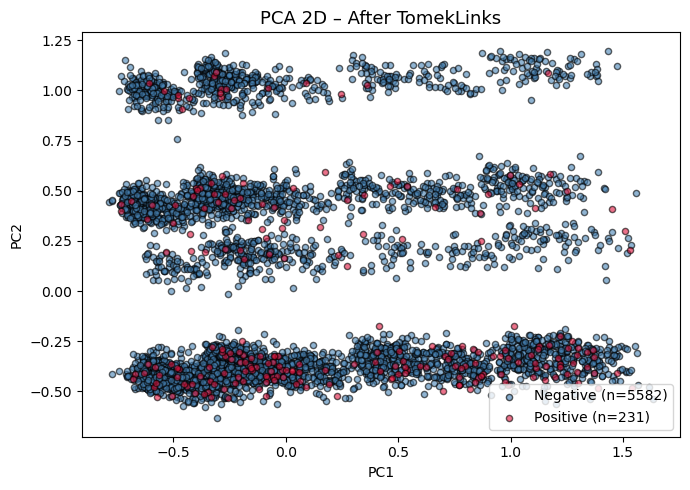

In [261]:
X_pca_tl = pca.transform(X_tl)
plot_pca(X_pca_tl, y_tl, title='PCA 2D – After TomekLinks')

=== Decision Tree – TomekLinks ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2423
           1       0.20      0.21      0.21        99

    accuracy                           0.94      2522
   macro avg       0.59      0.59      0.59      2522
weighted avg       0.94      0.94      0.94      2522



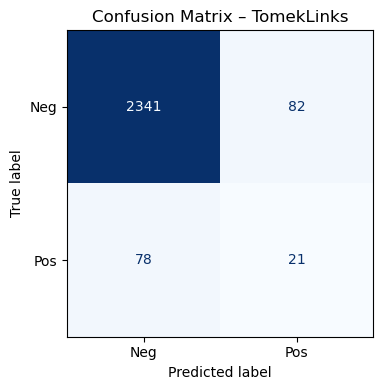

In [262]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Fit su dati TomekLinks
clf_tl = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_tl.fit(X_tl, y_tl)

# Predict
y_pred_tl = clf_tl.predict(X_test)
y_val_pred_proba_tl = clf_tl.predict_proba(X_test)

print("=== Decision Tree – TomekLinks ===")
print(classification_report(y_test, y_pred_tl))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tl, ax=ax,
                                        display_labels=['Neg', 'Pos'],
                                        colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – TomekLinks')
plt.tight_layout()
plt.show()

In [263]:
enn = EditedNearestNeighbours()
X_enn, y_enn = enn.fit_resample(X_train, y_train)
print(f"Resampled dataset shape: {Counter(y_enn)}")


Resampled dataset shape: Counter({0: 5149, 1: 231})


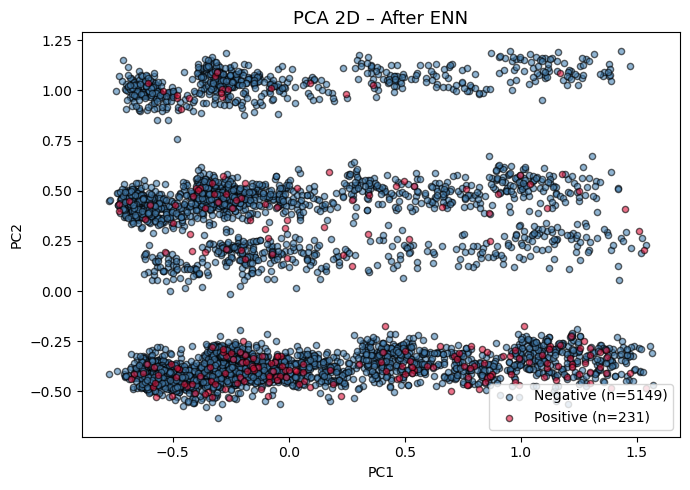

In [264]:
# PCA visualization
X_pca_enn = pca.transform(X_enn)
plot_pca(X_pca_enn, y_enn, title='PCA 2D – After ENN')

=== Decision Tree – ENN ===
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      2423
           1       0.14      0.17      0.16        99

    accuracy                           0.93      2522
   macro avg       0.55      0.56      0.56      2522
weighted avg       0.93      0.93      0.93      2522



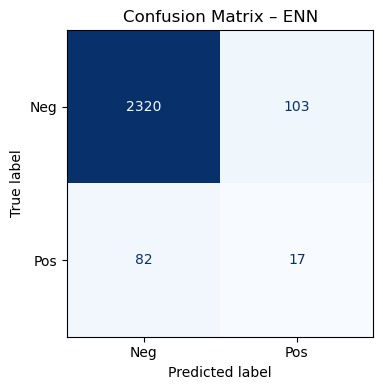

In [265]:
# Decision Tree
clf_enn = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_enn.fit(X_enn, y_enn)
y_pred_enn = clf_enn.predict(X_test)
y_val_pred_proba_enn = clf_enn.predict_proba(X_test)

print("=== Decision Tree – ENN ===")
print(classification_report(y_test, y_pred_enn))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_enn, ax=ax,
                                        display_labels=['Neg', 'Pos'],
                                        colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – ENN')
plt.tight_layout()
plt.show()

In [266]:
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import ClusterCentroids

In [267]:
cc = ClusterCentroids(
    estimator=MiniBatchKMeans(n_init=1, random_state=0), random_state=42
)
X_cc, y_cc = cc.fit_resample(X_train, y_train)
print(f"Resampled dataset shape: {Counter(y_cc)}")

Resampled dataset shape: Counter({0: 231, 1: 231})


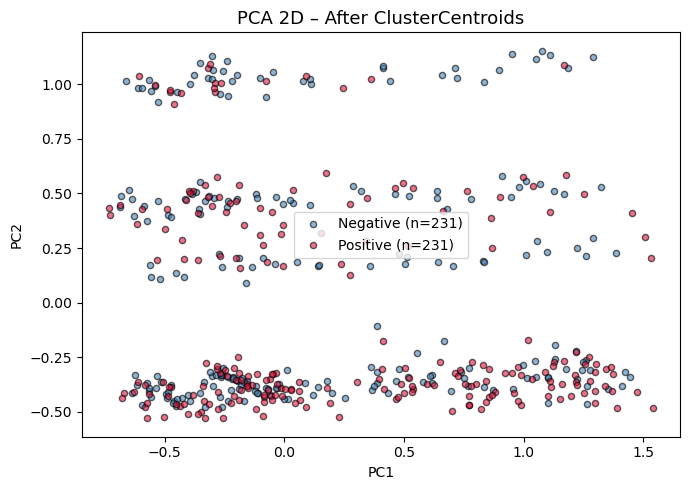

In [268]:
# PCA visualization
X_pca_cc = pca.transform(X_cc)
plot_pca(X_pca_cc, y_cc, title='PCA 2D – After ClusterCentroids')

=== Decision Tree – ClusterCentroids ===
              precision    recall  f1-score   support

           0       0.99      0.16      0.27      2423
           1       0.04      0.96      0.08        99

    accuracy                           0.19      2522
   macro avg       0.52      0.56      0.18      2522
weighted avg       0.95      0.19      0.26      2522



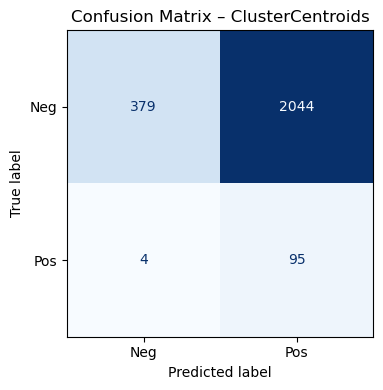

In [269]:
# Decision Tree
clf_cc = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_cc.fit(X_cc, y_cc)
y_pred_cc = clf_cc.predict(X_test)
y_val_pred_proba_cc = clf_cc.predict_proba(X_test)

print("=== Decision Tree – ClusterCentroids ===")
print(classification_report(y_test, y_pred_cc))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cc, ax=ax,
                                        display_labels=['Neg', 'Pos'],
                                        colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – ClusterCentroids')
plt.tight_layout()
plt.show()

In [270]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

In [271]:
# Random Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)
print(f"Resampled dataset shape: {Counter(y_ros)}")

Resampled dataset shape: Counter({0: 5651, 1: 5651})


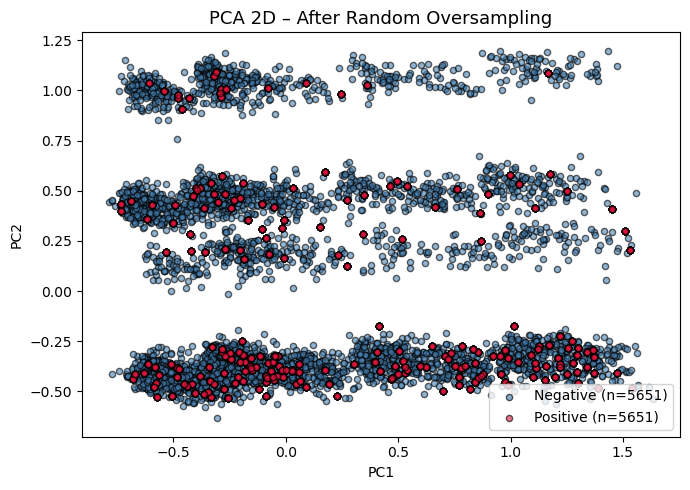

In [272]:
# PCA visualization
X_pca_ros = pca.transform(X_ros)
plot_pca(X_pca_ros, y_ros, title='PCA 2D – After Random Oversampling')

=== Decision Tree – Random Oversampling ===
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      2423
           1       0.18      0.23      0.20        99

    accuracy                           0.93      2522
   macro avg       0.57      0.59      0.58      2522
weighted avg       0.94      0.93      0.93      2522



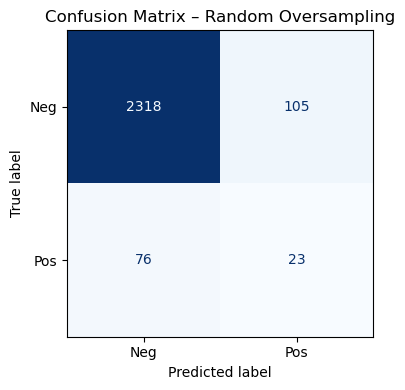

In [273]:
# Decision Tree
clf_ros = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_ros.fit(X_ros, y_ros)
y_pred_ros = clf_ros.predict(X_test)
y_val_pred_proba_ros = clf_ros.predict_proba(X_test)

print("=== Decision Tree – Random Oversampling ===")
print(classification_report(y_test, y_pred_ros))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ros, ax=ax,
                                        display_labels=['Neg', 'Pos'],
                                        colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – Random Oversampling')
plt.tight_layout()
plt.show()

In [274]:
sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_train, y_train)
print(f"Resampled dataset shape: {Counter(y_sm)}")

Resampled dataset shape: Counter({0: 5651, 1: 5651})


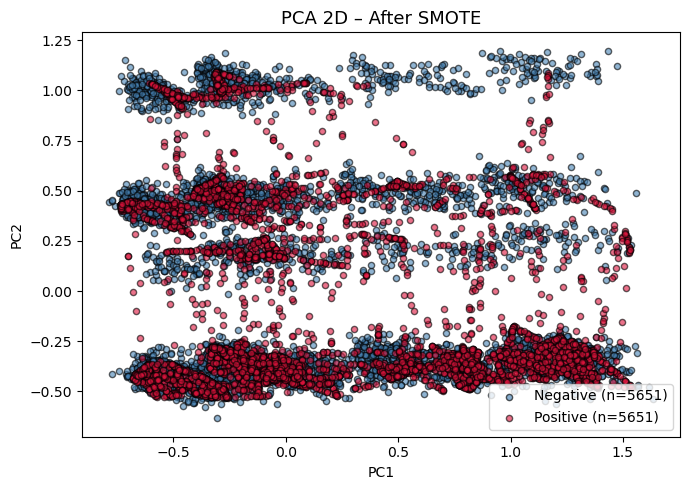

In [275]:
# PCA visualization
X_pca_sm = pca.transform(X_sm)
plot_pca(X_pca_sm, y_sm, title='PCA 2D – After SMOTE')

=== Decision Tree – SMOTE ===
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      2423
           1       0.10      0.19      0.14        99

    accuracy                           0.90      2522
   macro avg       0.54      0.56      0.54      2522
weighted avg       0.93      0.90      0.92      2522



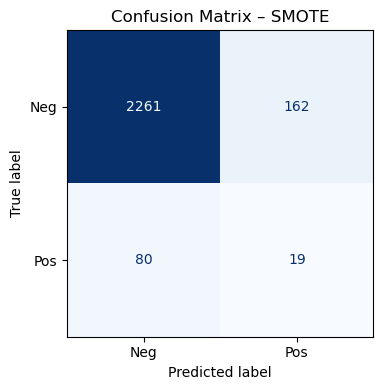

In [276]:
# Decision Tree
clf_sm = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_sm.fit(X_sm, y_sm)
y_pred_sm = clf_sm.predict(X_test)
y_val_pred_proba_sm = clf_sm.predict_proba(X_test)

print("=== Decision Tree – SMOTE ===")
print(classification_report(y_test, y_pred_sm))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_sm, ax=ax,
                                        display_labels=['Neg', 'Pos'],
                                        colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – SMOTE')
plt.tight_layout()
plt.show()

In [277]:
ada = ADASYN(random_state=42)
X_ada, y_ada = ada.fit_resample(X_train, y_train)
print(f"Resampled dataset shape: {Counter(y_ada)}")

Resampled dataset shape: Counter({0: 5651, 1: 5561})


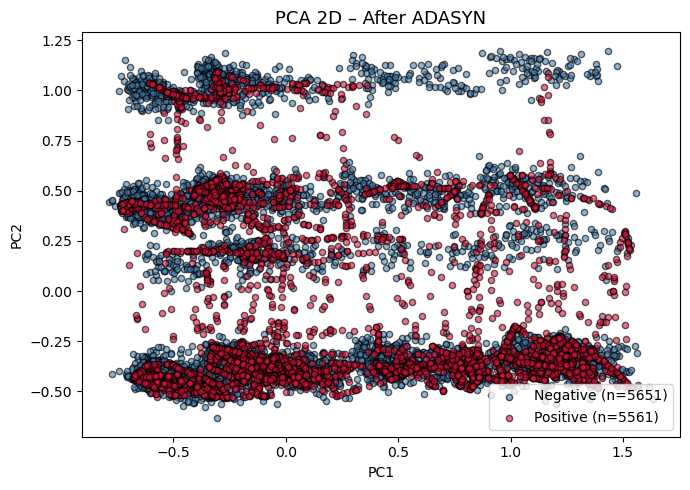

In [278]:
# PCA visualization
X_pca_ada = pca.transform(X_ada)
plot_pca(X_pca_ada, y_ada, title='PCA 2D – After ADASYN')

=== Decision Tree – ADASYN ===
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      2423
           1       0.11      0.22      0.15        99

    accuracy                           0.90      2522
   macro avg       0.54      0.57      0.55      2522
weighted avg       0.93      0.90      0.91      2522



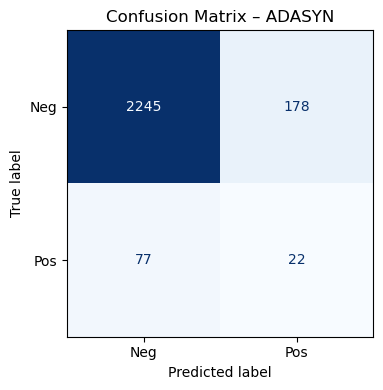

In [279]:
# Decision Tree
clf_ada = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_ada.fit(X_ada, y_ada)
y_pred_ada = clf_ada.predict(X_test)
y_val_pred_proba_ada = clf_ada.predict_proba(X_test)

print("=== Decision Tree – ADASYN ===")
print(classification_report(y_test, y_pred_ada))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ada, ax=ax,
                                        display_labels=['Neg', 'Pos'],
                                        colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – ADASYN')
plt.tight_layout()
plt.show()

                  Accuracy  Precision  Recall     F1
Method                                              
Baseline             0.937      0.159   0.141  0.150
RUS                  0.690      0.091   0.768  0.163
CNN                  0.854      0.128   0.465  0.200
TomekLinks           0.937      0.204   0.212  0.208
ENN                  0.927      0.142   0.172  0.155
ClusterCentroids     0.188      0.044   0.960  0.085
ROS                  0.928      0.180   0.232  0.203
SMOTE                0.904      0.105   0.192  0.136
ADASYN               0.899      0.110   0.222  0.147


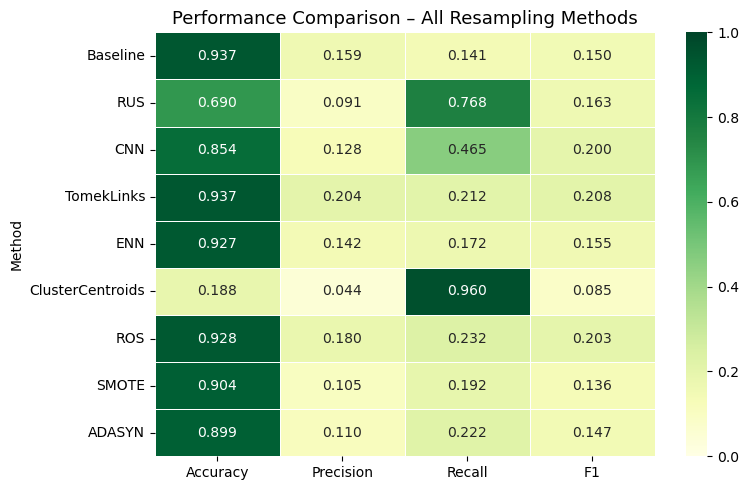

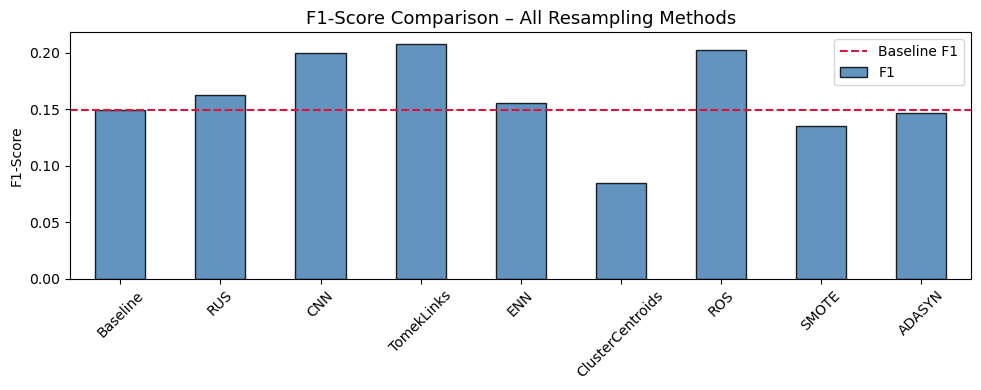

In [315]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Dizionario con tutti i metodi
results = {
    'Baseline':          (y_test, y_pred_og),
    'RUS':               (y_test, y_pred_rus),
    'CNN':               (y_test, y_pred_cnn),
    'TomekLinks':        (y_test, y_pred_tl),
    'ENN':               (y_test, y_pred_enn),
    'ClusterCentroids':  (y_test, y_pred_cc),
    'ROS':               (y_test, y_pred_ros),
    'SMOTE':             (y_test, y_pred_sm),
    'ADASYN':            (y_test, y_pred_ada),
}

rows = []
for name, (yt, yp) in results.items():
    rows.append({
        'Method':    name,
        'Accuracy':  accuracy_score(yt, yp),
        'Precision': precision_score(yt, yp, zero_division=0),
        'Recall':    recall_score(yt, yp, zero_division=0),
        'F1':        f1_score(yt, yp, zero_division=0),
    })

results_df = pd.DataFrame(rows).set_index('Method')
print(results_df.round(3).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(results_df.astype(float), annot=True, fmt='.3f',
            cmap='YlGn', vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Performance Comparison – All Resampling Methods', fontsize=13)
plt.tight_layout()
plt.show()

# Bar chart F1
fig, ax = plt.subplots(figsize=(10, 4))
results_df['F1'].plot(kind='bar', ax=ax, color='steelblue', 
                      edgecolor='k', alpha=0.85)
ax.axhline(results_df.loc['Baseline', 'F1'], color='crimson', 
           linestyle='--', label='Baseline F1')
ax.set_title('F1-Score Comparison – All Resampling Methods', fontsize=13)
ax.set_ylabel('F1-Score')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('f1_comparison_resampling.png', dpi=300, bbox_inches='tight')
plt.show()

In [281]:
from sklearn.metrics import roc_auc_score

probas = {
    'Baseline':         y_val_pred_proba_og[:,1],
    'RUS':              y_val_pred_proba_rus[:,1],
    'CNN':              y_val_pred_proba_cnn[:,1],
    'TomekLinks':       y_val_pred_proba_tl[:,1],
    'ENN':              y_val_pred_proba_enn[:,1],
    'ClusterCentroids': y_val_pred_proba_cc[:,1],
    'ROS':              y_val_pred_proba_ros[:,1],
    'SMOTE':            y_val_pred_proba_sm[:,1],
    'ADASYN':           y_val_pred_proba_ada[:,1],
}
for name, proba in probas.items():
    auc = roc_auc_score(y_test, proba)
    print(f"{name:20s} ROC-AUC: {auc:.4f}")

Baseline             ROC-AUC: 0.5987
RUS                  ROC-AUC: 0.7631
CNN                  ROC-AUC: 0.6876
TomekLinks           ROC-AUC: 0.6042
ENN                  ROC-AUC: 0.6148
ClusterCentroids     ROC-AUC: 0.5636
ROS                  ROC-AUC: 0.5948
SMOTE                ROC-AUC: 0.5868
ADASYN               ROC-AUC: 0.6181


In [282]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek, SMOTEENN

# Combinazione 1 — SMOTETomek (già implementata in imblearn)
smt = SMOTETomek(random_state=42)
X_smt, y_smt = smt.fit_resample(X_train, y_train)
print(f"SMOTETomek: {Counter(y_smt)}")

# Combinazione 2 — SMOTEENN
smenn = SMOTEENN(random_state=42)
X_smenn, y_smenn = smenn.fit_resample(X_train, y_train)
print(f"SMOTEENN: {Counter(y_smenn)}")

SMOTETomek: Counter({0: 5651, 1: 5651})
SMOTEENN: Counter({1: 5643, 0: 4511})


=== Decision Tree – SMOTETomek ===
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      2423
           1       0.10      0.19      0.14        99

    accuracy                           0.90      2522
   macro avg       0.54      0.56      0.54      2522
weighted avg       0.93      0.90      0.92      2522

=== Decision Tree – SMOTEENN ===
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      2423
           1       0.12      0.35      0.17        99

    accuracy                           0.87      2522
   macro avg       0.54      0.62      0.55      2522
weighted avg       0.94      0.87      0.90      2522



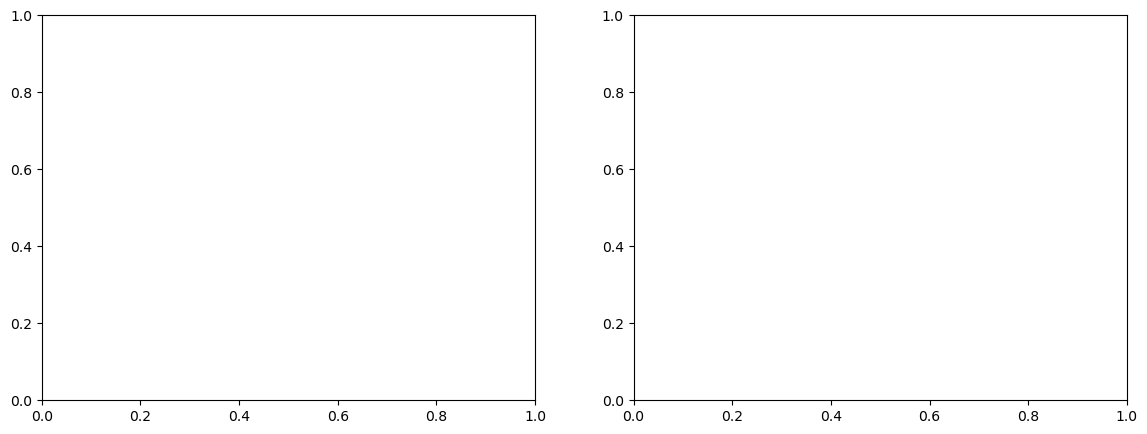

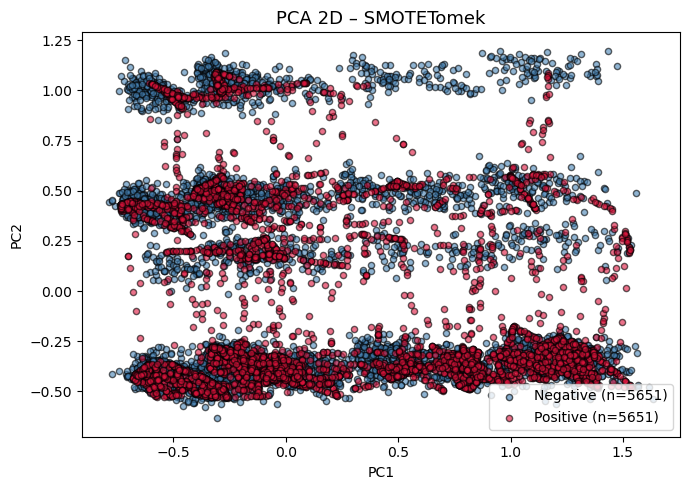

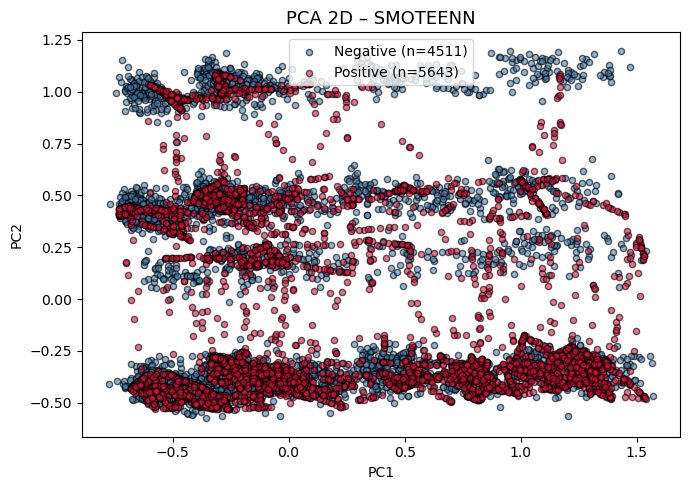

In [283]:
# Decision Tree – SMOTETomek
clf_smt = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_smt.fit(X_smt, y_smt)
y_pred_smt = clf_smt.predict(X_test)
y_val_pred_proba_smt = clf_smt.predict_proba(X_test)

print("=== Decision Tree – SMOTETomek ===")
print(classification_report(y_test, y_pred_smt))

# Decision Tree – SMOTEENN
clf_smenn = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_smenn.fit(X_smenn, y_smenn)
y_pred_smenn = clf_smenn.predict(X_test)
y_val_pred_proba_smenn = clf_smenn.predict_proba(X_test)

print("=== Decision Tree – SMOTEENN ===")
print(classification_report(y_test, y_pred_smenn))

# PCA visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_pca(pca.transform(X_smt), y_smt, title='PCA 2D – SMOTETomek')
plot_pca(pca.transform(X_smenn), y_smenn, title='PCA 2D – SMOTEENN')

In [284]:
results = {
    'Baseline':         (y_test, y_pred_og),
    'RUS':              (y_test, y_pred_rus),
    'CNN':              (y_test, y_pred_cnn),
    'TomekLinks':       (y_test, y_pred_tl),
    'ENN':              (y_test, y_pred_enn),
    'ClusterCentroids': (y_test, y_pred_cc),
    'ROS':              (y_test, y_pred_ros),
    'SMOTE':            (y_test, y_pred_sm),
    'ADASYN':           (y_test, y_pred_ada),
    'SMOTETomek':       (y_test, y_pred_smt),
    'SMOTEENN':         (y_test, y_pred_smenn),
}


✓ RUS                  + ROS
✓ RUS                  + SMOTE
✓ RUS                  + ADASYN
✓ TomekLinks           + ROS
✓ TomekLinks           + SMOTE
✓ TomekLinks           + ADASYN
✓ ENN                  + ROS
✓ ENN                  + SMOTE
✓ ENN                  + ADASYN
✓ CNN                  + ROS
✓ CNN                  + SMOTE
✓ CNN                  + ADASYN
✓ ClusterCentroids     + ROS
✓ ClusterCentroids     + SMOTE
✓ ClusterCentroids     + ADASYN

=== RANKING PER F1 ===
Combo
CNN + ROS                    0.214
ENN + ADASYN                 0.200
ENN + ROS                    0.191
TomekLinks + SMOTE           0.182
CNN + ADASYN                 0.174
TomekLinks + ROS             0.166
RUS + ROS                    0.163
RUS + SMOTE                  0.163
RUS + ADASYN                 0.163
ENN + SMOTE                  0.161
TomekLinks + ADASYN          0.131
CNN + SMOTE                  0.118
ClusterCentroids + ROS       0.085
ClusterCentroids + SMOTE     0.085
ClusterCentroids + A

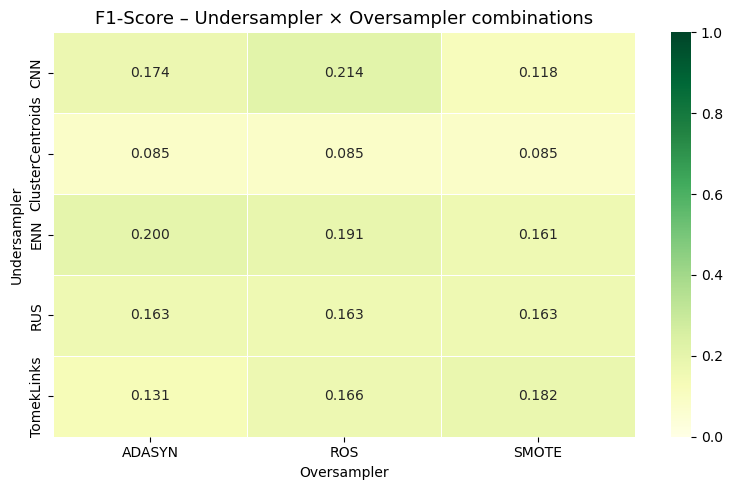

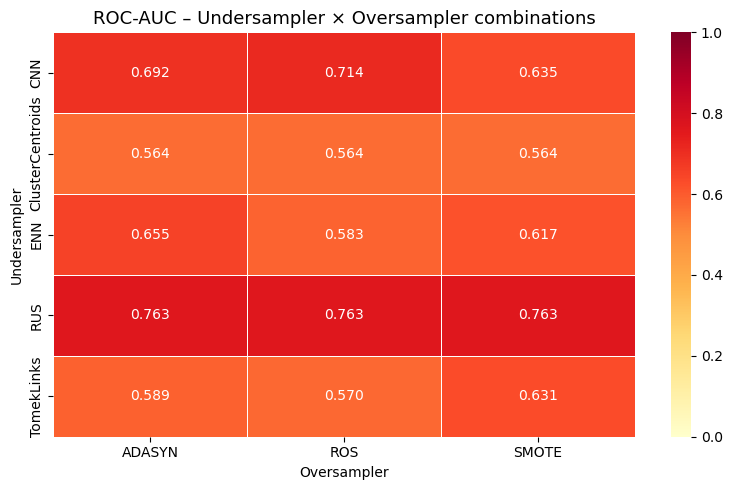


🏆 Miglior combinazione: CNN + ROS
Undersampler         CNN
Oversampler          ROS
Accuracy        0.845757
Precision       0.133838
Recall          0.535354
F1              0.214141
ROC-AUC         0.713607
Name: CNN + ROS, dtype: object


In [285]:
from itertools import product
from imblearn.pipeline import Pipeline as ImbPipeline

undersamplers = {
    'RUS':              RandomUnderSampler(random_state=42),
    'TomekLinks':       TomekLinks(),
    'ENN':              EditedNearestNeighbours(),
    'CNN':              CondensedNearestNeighbour(random_state=42, n_jobs=10),
    'ClusterCentroids': ClusterCentroids(estimator=MiniBatchKMeans(n_init=1, random_state=0), random_state=42),
}

oversamplers = {
    'ROS':   RandomOverSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
}

combo_rows = []

for u_name, o_name in product(undersamplers.keys(), oversamplers.keys()):
    try:
        # Pipeline: prima undersample poi oversample
        pipe = ImbPipeline([
            ('under', undersamplers[u_name]),
            ('over',  oversamplers[o_name]),
        ])
        X_combo, y_combo = pipe.fit_resample(X_train, y_train)
        
        # Fit DT
        clf_combo = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
        clf_combo.fit(X_combo, y_combo)
        
        # Predict
        y_pred_combo = clf_combo.predict(X_test)
        y_proba_combo = clf_combo.predict_proba(X_test)[:,1]
        
        combo_rows.append({
            'Undersampler': u_name,
            'Oversampler':  o_name,
            'Combo':        f'{u_name} + {o_name}',
            'Accuracy':     accuracy_score(y_test, y_pred_combo),
            'Precision':    precision_score(y_test, y_pred_combo, zero_division=0),
            'Recall':       recall_score(y_test, y_pred_combo, zero_division=0),
            'F1':           f1_score(y_test, y_pred_combo, zero_division=0),
            'ROC-AUC':      roc_auc_score(y_test, y_proba_combo),
        })
        print(f"✓ {u_name:20s} + {o_name}")
        
    except Exception as e:
        print(f"✗ {u_name} + {o_name} → {e}")

combo_df = pd.DataFrame(combo_rows).set_index('Combo')

# Ranking
print("\n=== RANKING PER F1 ===")
print(combo_df['F1'].sort_values(ascending=False).round(3))

print("\n=== RANKING PER ROC-AUC ===")
print(combo_df['ROC-AUC'].sort_values(ascending=False).round(3))

# Heatmap F1
pivot_f1 = combo_df.pivot(index='Undersampler', columns='Oversampler', values='F1')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='YlGn', 
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('F1-Score – Undersampler × Oversampler combinations', fontsize=13)
plt.tight_layout()
plt.show()

# Heatmap ROC-AUC
pivot_auc = combo_df.pivot(index='Undersampler', columns='Oversampler', values='ROC-AUC')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_auc, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('ROC-AUC – Undersampler × Oversampler combinations', fontsize=13)
plt.tight_layout()
plt.show()

# Miglior combo
best = combo_df['F1'].idxmax()
print(f"\n🏆 Miglior combinazione: {best}")
print(combo_df.loc[best].round(3))

                           Recall  Precision     F1
Combo                                              
ClusterCentroids + ROS      0.960      0.044  0.085
ClusterCentroids + SMOTE    0.960      0.044  0.085
ClusterCentroids + ADASYN   0.960      0.044  0.085
RUS + ROS                   0.768      0.091  0.163
RUS + SMOTE                 0.768      0.091  0.163
RUS + ADASYN                0.768      0.091  0.163
CNN + ROS                   0.535      0.134  0.214
CNN + ADASYN                0.525      0.104  0.174
ENN + ADASYN                0.354      0.139  0.200
CNN + SMOTE                 0.333      0.072  0.118
TomekLinks + SMOTE          0.283      0.134  0.182
ENN + SMOTE                 0.273      0.114  0.161
ENN + ROS                   0.202      0.182  0.191
TomekLinks + ADASYN         0.192      0.099  0.131
TomekLinks + ROS            0.182      0.153  0.166


Resampled dataset shape: Counter({0: 231, 1: 231})
=== Decision Tree – RUS + ROS ===
              precision    recall  f1-score   support

           0       0.99      0.69      0.81      2423
           1       0.09      0.77      0.16        99

    accuracy                           0.69      2522
   macro avg       0.54      0.73      0.49      2522
weighted avg       0.95      0.69      0.78      2522



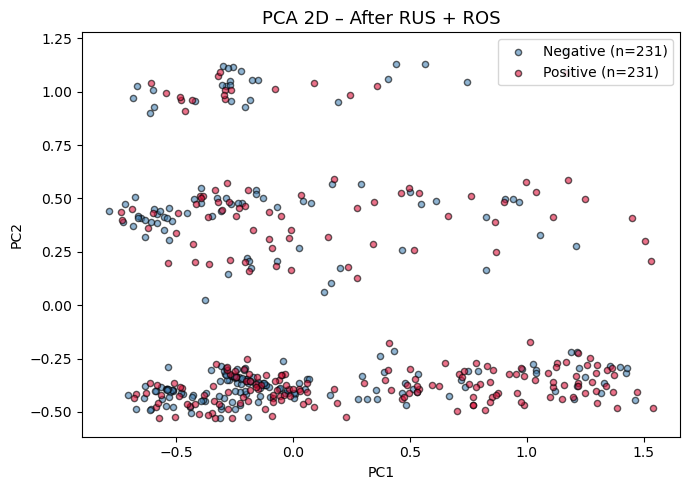

<Figure size 640x480 with 0 Axes>

In [331]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Pipeline RUS + ROS (stesso ordine usato nel loop combo: prima under, poi over)
pipe_rus_ros = ImbPipeline([
    ('under', RandomUnderSampler(random_state=42)),
    ('over',  RandomOverSampler(random_state=42)),
])
X_rus_ros, y_rus_ros = pipe_rus_ros.fit_resample(X_train, y_train)
print(f"Resampled dataset shape: {Counter(y_rus_ros)}")

# Decision Tree sulla combo scelta
clf_rus_ros = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_rus_ros.fit(X_rus_ros, y_rus_ros)

y_pred_rus_ros = clf_rus_ros.predict(X_test)
y_val_pred_proba_rus_ros = clf_rus_ros.predict_proba(X_test)

print("=== Decision Tree – RUS + ROS ===")
print(classification_report(y_test, y_pred_rus_ros))




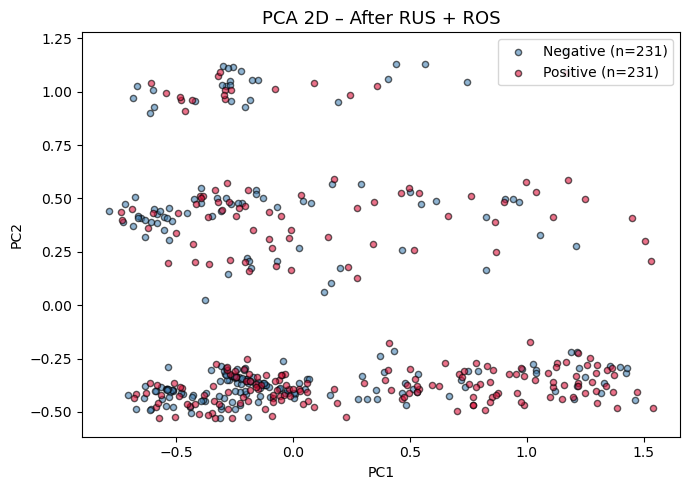

In [337]:
# PCA visualization
X_pca_rus_ros = pca.transform(X_rus_ros)

fig, ax = plt.subplots(figsize=(7, 5))
for label, color, name in zip([0, 1], ['steelblue', 'crimson'], ['Negative', 'Positive']):
    mask = np.array(y_rus_ros) == label
    ax.scatter(X_pca_rus_ros[mask, 0], X_pca_rus_ros[mask, 1],
               c=color, edgecolor='k', alpha=0.6,
               s=20, label=f'{name} (n={mask.sum()})')
ax.set_title('PCA 2D – After RUS + ROS', fontsize=13)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('pca_res_ros.png', dpi=300, bbox_inches='tight')  # salvo PRIMA di show()
plt.show()

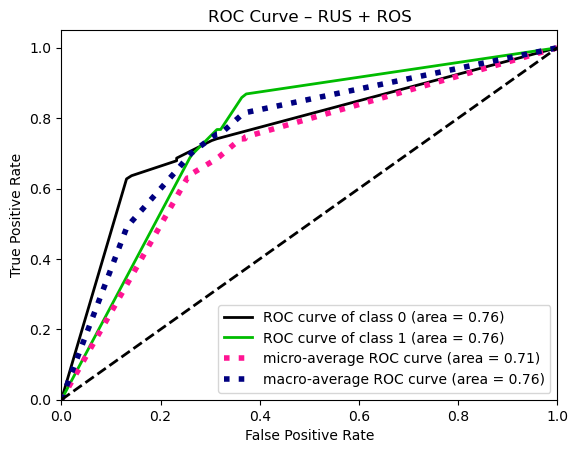

In [323]:
plot_roc(y_test, y_val_pred_proba_rus_ros, title='ROC Curve – RUS + ROS')
plt.savefig('combo_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()